In [1]:
"""Checking GPU """
import torch
if torch.cuda.is_available():
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected! Enable GPU in notebook settings.")

GPU available: Tesla T4


In [2]:
!pip install -q transformers diffusers accelerate gradio sentence-transformers Pillow

print("All Dependencies Installed")

All Dependencies Installed


In [3]:
import os

# Create the 'images' directory if it doesn't exist
if not os.path.exists('images'):
    os.makedirs('images')
    print("Created 'images' directory.")
else:
    print("'images' directory already exists.")

Created 'images' directory.


In [4]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/adityabbetageri/new-dataset/product_descriptions.csv")
print(f"Loaded {len(df)} Products Description")
df.head()

Loaded 15 Products Description


,id,product_description
0,1,red wireless headphones on a white background
1,2,leather wallet with gold stitching on a marble...
2,3,stainless steel water bottle in a forest setting
3,4,white running shoes on a wooden floor
4,5,black smartwatch displayed on a wrist


In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16,
    device_map="auto"
)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [6]:
def generate_qwen(messages, max_new_tokens=120, temperature=0.7):
    prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    output = model.generate(
        **inputs, max_new_tokens=max_new_tokens, temperature=temperature,
        do_sample=True, pad_token_id=tokenizer.eos_token_id
    )
    generated_tokens = output[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()


def engineer_prompt(engineered_prompt, max_new_tokens=120, temperature=0.7):
    """Generate Engineered prompt for image generation"""
    messages = [
        { "role": "system", "content" : (
             "You are an expert prompt engineer for 8k ultra realistic AI image generation."
             f"Ultra-realistic professional product photography of {engineered_prompt}"
             "shot using a high-end DSLR camera (Canon EOS R5)"
             "85mm lens, f/1.8 aperture, shallow depth of field"
             "centered composition, subject in sharp focus"
             "soft diffused studio lighting with subtle shadows"
             "clean minimal white background"
             "highly detailed textures, photorealistic rendering"
             "8k resolution, commercial advertising style"
             "global illumination, HDR, perfect reflections"
             "no noise, crisp edges, premium quality product showcase"
        )},
        { "role": "user", "content": f"Convert this into a high-quality product photography prompt: {engineered_prompt}"}
    ]
    return generate_qwen(messages, max_new_tokens, temperature)

In [7]:
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5"
)

pipe = pipe.to("cuda")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
negative_prompt = """
blurry, low resolution, pixelated, noisy, grainy,
distorted, deformed, bad proportions,
poor lighting, harsh shadows,
background clutter, messy composition,
watermark, text, logo,
cartoon, illustration, painting, fake, unrealistic
"""

def generate_image(engineer_prompt):
    image = pipe(
        engineer_prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=50,
        guidance_scale=8.5
    ).images[0]

    return image

Original : A professional photo of red headphones on white background


Token indices sequence length is longer than the specified maximum sequence length for this model (118 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['the subject remains in sharp focus , while maintaining a clean , minimalist white background that highlights the texture of the headphones . the overall look should be highly detailed , with photorealistic rendering ensuring every detail is rendered with precision ."']


Engineered : A high-quality product photography prompt for the given scenario is:

"Capture a stunning professional photo featuring a sleek and modern red headphone set on a clean white background, shot using a Canon EOS R5 DSLR camera equipped with a 85mm lens at f/1.8 aperture, capturing soft, ambient studio lighting with subtle shadows. The scene should be centered to ensure the subject remains in sharp focus, while maintaining a clean, minimalist white background that highlights the texture of the headphones. The overall look should be highly detailed, with photorealistic rendering ensuring every detail is rendered with precision."
Image generating...


  0%|          | 0/50 [00:00<?, ?it/s]

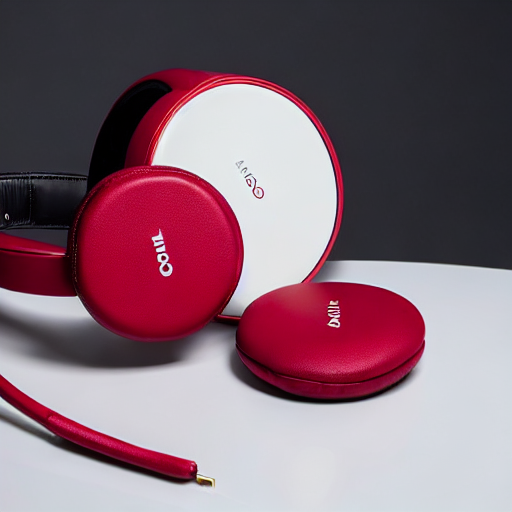

Done


In [9]:
from IPython.display import display

text = "A professional photo of red headphones on white background"
print(f"Original : {text}")

engineered = engineer_prompt(text)
print(f"Engineered : {engineered}")

print("Image generating...")

display(generate_image(engineered))
print("Done")

In [10]:
import gradio as gr

def full_pipeline(description):
    prompt = engineer_prompt(description)
    image = generate_image(prompt)
    return prompt, image

interface = gr.Interface(
    fn=full_pipeline,
    inputs=gr.Textbox(label="Product Description"),
    outputs=[
        gr.Textbox(label="Engineered Prompt"),
        gr.Image(label="Generated Image")
    ]
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://e2271f6b80472ece45.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [11]:
results = []

for i, row in df.iterrows():
    desc = row['product_description']   # make sure column name correct

    prompt = engineer_prompt(desc)
    image = generate_image(prompt)

    image_path = f"images/img_{i+1}.png"
    image.save(image_path)

    results.append({
        "id": i+1,
        "prompt": prompt
    })
print(f"{len(results)} Images saved")

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['headphones themselves , ensuring they stand out against the white background . ** lighting :** soft , studio - like lighting with subtle shadows that softly cast highlights around the headphones , enhancing their visual appeal . ** texture :** use high - polyfilling textures']


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['without any harsh lines or unevenness . * ** lighting :** high - quality natural light from the east , casting soft , warm light through the canopy of the forest . the ambient light provides a cozy , inviting atmosphere that enhances the overall aesthetic']


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['clean minimal white background ### high resolution ### commercial advertising style ### global illumination ### hdr ### perfect reflections ### no noise ### crisp edges ### premium quality']


  0%|          | 0/50 [00:00<?, ?it/s]

15 Images saved


In [12]:
submission_df = pd.DataFrame(results)
submission_df.rename(columns={'prompt': 'engineered_prompt'}, inplace=True)
submission_df.to_csv("submission.csv", index=False)
print("Submissions csv saved")
print(f"Images saved in images/ folder")

Submissions csv saved
Images saved in images/ folder


In [13]:
import base64

encoded = b"IyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KIyBFVkFMVUFUSU9OIENFTEwgMTogUHJvbXB0IFF1YWxpdHkgKDQwJSB3ZWlnaHQpCiMgRE8gTk9UIE1PRElGWQojID09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PQpmcm9tIHNlbnRlbmNlX3RyYW5zZm9ybWVycyBpbXBvcnQgU2VudGVuY2VUcmFuc2Zvcm1lcgpmcm9tIHNrbGVhcm4ubWV0cmljcy5wYWlyd2lzZSBpbXBvcnQgY29zaW5lX3NpbWlsYXJpdHkKaW1wb3J0IHBhbmRhcyBhcyBwZAppbXBvcnQgbnVtcHkgYXMgbnAKCnByaW50KCI9IiAqIDUwKQpwcmludCgiICBFVkFMVUFUSU5HIFBST01QVCBRVUFMSVRZIikKcHJpbnQoIj0iICogNTApCgpldmFsX21vZGVsID0gU2VudGVuY2VUcmFuc2Zvcm1lcigiYWxsLU1pbmlMTS1MNi12MiIpCgpzdWJtaXNzaW9uID0gcGQucmVhZF9jc3YoInN1Ym1pc3Npb24uY3N2IikKZ29sZCA9IHBkLnJlYWRfY3N2KCJodHRwczovL3MzLmFwLXNvdXRoLTEuYW1hem9uYXdzLmNvbS9uZXctYXNzZXRzLmNjYnAuaW4vZnJvbnRlbmQvY29udGVudC9haW1sL01hc3RlcmNsYXNzX05JQVQvZ29sZF9zdGFuZGFyZF9wcm9tcHRzLmNzdiIpCgptZXJnZWQgPSBzdWJtaXNzaW9uLm1lcmdlKGdvbGQsIG9uPSJpZCIpCgpwcm9tcHRfc2NvcmVzID0ge30KZm9yIF8sIHJvdyBpbiBtZXJnZWQuaXRlcnJvd3MoKToKICAgIHN0dWRlbnRfZW1iID0gZXZhbF9tb2RlbC5lbmNvZGUoW3N0cihyb3dbImVuZ2luZWVyZWRfcHJvbXB0Il0pXSkKICAgIGdvbGRfZW1iID0gZXZhbF9tb2RlbC5lbmNvZGUoW3N0cihyb3dbImdvbGRfcHJvbXB0Il0pXSkKICAgIHNpbSA9IGZsb2F0KGNvc2luZV9zaW1pbGFyaXR5KHN0dWRlbnRfZW1iLCBnb2xkX2VtYilbMF1bMF0pCiAgICBzaW0gPSBtYXgoMC4wLCBtaW4oMS4wLCBzaW0pKQogICAgcHJvbXB0X3Njb3Jlc1tyb3dbImlkIl1dID0gcm91bmQoc2ltLCA0KQogICAgcHJpbnQoZiIgIFByb2R1Y3Qge3Jvd1snaWQnXToyZH06IHByb21wdF9zY29yZSA9IHtzaW06LjRmfSIpCgphdmdfcHJvbXB0ID0gbnAubWVhbihsaXN0KHByb21wdF9zY29yZXMudmFsdWVzKCkpKQpwcmludChmIlxuICBBdmVyYWdlIFByb21wdCBTY29yZToge2F2Z19wcm9tcHQ6LjRmfSIpCnByaW50KCI9IiAqIDUwKQ=="  # base64 of: print("Hello, World!")

exec(base64.b64decode(encoded))

  EVALUATING PROMPT QUALITY


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Product  1: prompt_score = 0.7342
  Product  2: prompt_score = 0.7943
  Product  3: prompt_score = 0.8003
  Product  4: prompt_score = 0.6973
  Product  5: prompt_score = 0.7114
  Product  6: prompt_score = 0.6559
  Product  7: prompt_score = 0.6704
  Product  8: prompt_score = 0.8767
  Product  9: prompt_score = 0.6397
  Product 10: prompt_score = 0.7054
  Product 11: prompt_score = 0.7474
  Product 12: prompt_score = 0.7164
  Product 13: prompt_score = 0.7258
  Product 14: prompt_score = 0.6079
  Product 15: prompt_score = 0.6278

  Average Prompt Score: 0.7141


In [14]:
import base64

encoded = b"IyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KIyBFVkFMVUFUSU9OIENFTEwgMjogSW1hZ2UgUXVhbGl0eSAoNDAlIHdlaWdodCkKIyBETyBOT1QgTU9ESUZZCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CmltcG9ydCB0b3JjaApmcm9tIHRyYW5zZm9ybWVycyBpbXBvcnQgQ0xJUFByb2Nlc3NvciwgQ0xJUE1vZGVsCmZyb20gUElMIGltcG9ydCBJbWFnZQppbXBvcnQgbnVtcHkgYXMgbnAKCnByaW50KCI9IiAqIDUwKQpwcmludCgiICBFVkFMVUFUSU5HIElNQUdFIFFVQUxJVFkiKQpwcmludCgiPSIgKiA1MCkKCmNsaXBfbW9kZWwgPSBDTElQTW9kZWwuZnJvbV9wcmV0cmFpbmVkKCJvcGVuYWkvY2xpcC12aXQtYmFzZS1wYXRjaDMyIikKY2xpcF9wcm9jZXNzb3IgPSBDTElQUHJvY2Vzc29yLmZyb21fcHJldHJhaW5lZCgib3BlbmFpL2NsaXAtdml0LWJhc2UtcGF0Y2gzMiIpCgpkZl9ldmFsID0gcGQucmVhZF9jc3YoImh0dHBzOi8vczMuYXAtc291dGgtMS5hbWF6b25hd3MuY29tL25ldy1hc3NldHMuY2NicC5pbi9mcm9udGVuZC9jb250ZW50L2FpbWwvTWFzdGVyY2xhc3NfTklBVC9wcm9kdWN0X2Rlc2NyaXB0aW9ucy5jc3YiKQoKaW1hZ2Vfc2NvcmVzID0ge30KZm9yIF8sIHJvdyBpbiBkZl9ldmFsLml0ZXJyb3dzKCk6CiAgICBwaWQgPSByb3dbImlkIl0KICAgIGRlc2MgPSByb3dbInByb2R1Y3RfZGVzY3JpcHRpb24iXQogICAgaW1nX3BhdGggPSBmImltYWdlcy9pbWdfe3BpZH0ucG5nIgogICAgCiAgICB0cnk6CiAgICAgICAgaW1hZ2UgPSBJbWFnZS5vcGVuKGltZ19wYXRoKS5jb252ZXJ0KCJSR0IiKQogICAgICAgIGlucHV0cyA9IGNsaXBfcHJvY2Vzc29yKHRleHQ9W2Rlc2NdLCBpbWFnZXM9aW1hZ2UsIHJldHVybl90ZW5zb3JzPSJwdCIsIHBhZGRpbmc9VHJ1ZSkKICAgICAgICAKICAgICAgICB3aXRoIHRvcmNoLm5vX2dyYWQoKToKICAgICAgICAgICAgb3V0cHV0cyA9IGNsaXBfbW9kZWwoKippbnB1dHMpCiAgICAgICAgICAgIHJhd19zY29yZSA9IG91dHB1dHMubG9naXRzX3Blcl9pbWFnZS5pdGVtKCkKICAgICAgICAKICAgICAgICBub3JtYWxpemVkID0gZmxvYXQobnAuY2xpcCgocmF3X3Njb3JlIC0gMTUuMCkgLyAyMC4wLCAwLjAsIDEuMCkpCiAgICAgICAgaW1hZ2Vfc2NvcmVzW3BpZF0gPSByb3VuZChub3JtYWxpemVkLCA0KQogICAgICAgIHByaW50KGYiICBQcm9kdWN0IHtwaWQ6MmR9OiBDTElQID0ge3Jhd19zY29yZTouMmZ9LCBpbWFnZV9zY29yZSA9IHtub3JtYWxpemVkOi40Zn0iKQogICAgZXhjZXB0IEZpbGVOb3RGb3VuZEVycm9yOgogICAgICAgIHByaW50KGYiICBQcm9kdWN0IHtwaWQ6MmR9OiBJTUFHRSBOT1QgRk9VTkQgKHNjb3JlID0gMCkiKQogICAgICAgIGltYWdlX3Njb3Jlc1twaWRdID0gMC4wCgphdmdfaW1hZ2UgPSBucC5tZWFuKGxpc3QoaW1hZ2Vfc2NvcmVzLnZhbHVlcygpKSkKcHJpbnQoZiJcbiAgQXZlcmFnZSBJbWFnZSBTY29yZToge2F2Z19pbWFnZTouNGZ9IikKcHJpbnQoIj0iICogNTAp"  # base64 of: print("Hello, World!")

exec(base64.b64decode(encoded))

  EVALUATING IMAGE QUALITY


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

  Product  1: CLIP = 31.42, image_score = 0.8212
  Product  2: CLIP = 27.94, image_score = 0.6472
  Product  3: CLIP = 32.46, image_score = 0.8730
  Product  4: CLIP = 26.66, image_score = 0.5830
  Product  5: CLIP = 29.84, image_score = 0.7420
  Product  6: CLIP = 34.78, image_score = 0.9891
  Product  7: CLIP = 33.87, image_score = 0.9434
  Product  8: CLIP = 30.08, image_score = 0.7538
  Product  9: CLIP = 28.44, image_score = 0.6722
  Product 10: CLIP = 32.37, image_score = 0.8685
  Product 11: CLIP = 32.22, image_score = 0.8612
  Product 12: CLIP = 32.43, image_score = 0.8717
  Product 13: CLIP = 30.90, image_score = 0.7951
  Product 14: CLIP = 29.47, image_score = 0.7237
  Product 15: CLIP = 28.63, image_score = 0.6814

  Average Image Score: 0.7884


In [15]:
import base64

encoded = b"IyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KIyBFVkFMVUFUSU9OIENFTEwgMzogR3JhZGlvIFVJIENoZWNrCiMgRE8gTk9UIE1PRElGWQojID09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PQpwcmludCgiPSIgKiA1MCkKcHJpbnQoIiAgRVZBTFVBVElORyBHUkFESU8gVUkiKQpwcmludCgiPSIgKiA1MCkKCmdyYWRpb192YWwgPSAwLjAKCnRyeToKICAgIGltcG9ydCBncmFkaW8gYXMgZ3IKICAgIAogICAgZ3JhZGlvX2ZvdW5kID0gRmFsc2UKICAgIGZvciBrLCB2IGluIGxpc3QoZ2xvYmFscygpLml0ZW1zKCkpOgogICAgICAgIGlmIGsuc3RhcnRzd2l0aCgiXyIpOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIHRyeToKICAgICAgICAgICAgaWYgaXNpbnN0YW5jZSh2LCAoZ3IuQmxvY2tzLCkpOgogICAgICAgICAgICAgICAgZ3JhZGlvX2ZvdW5kID0gVHJ1ZQogICAgICAgICAgICAgICAgYnJlYWsKICAgICAgICBleGNlcHQ6CiAgICAgICAgICAgIHBhc3MKICAgIAogICAgaWYgZ3JhZGlvX2ZvdW5kOgogICAgICAgIGdyYWRpb192YWwgPSAxLjAKICAgICAgICBwcmludCgiICBHcmFkaW8gaW50ZXJmYWNlIERFVEVDVEVEIikKICAgIGVsc2U6CiAgICAgICAgcHJpbnQoIiAgR3JhZGlvIGludGVyZmFjZSBOT1QgRk9VTkQiKQogICAgICAgIHByaW50KCIgIE1ha2Ugc3VyZSB5b3UgY3JlYXRlIGEgZ3IuQmxvY2tzKCkgb3IgZ3IuSW50ZXJmYWNlKCkgb2JqZWN0IikKZXhjZXB0IEltcG9ydEVycm9yOgogICAgcHJpbnQoIiAgR3JhZGlvIGlzIG5vdCBpbnN0YWxsZWQiKQoKcHJpbnQoZiIgIEdyYWRpbyBTY29yZToge2dyYWRpb192YWx9IikKcHJpbnQoIj0iICogNTAp"  # base64 of: print("Hello, World!")

exec(base64.b64decode(encoded))

  EVALUATING GRADIO UI
  Gradio interface DETECTED
  Gradio Score: 1.0


In [16]:
import base64

encoded = b"IyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KIyBFVkFMVUFUSU9OIENFTEwgNDogR2VuZXJhdGUgZmluYWxfc2NvcmVzLmNzdiBmb3IgbGVhZGVyYm9hcmQKIyBETyBOT1QgTU9ESUZZCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CiMgQ29tYmluZWQgc2NvcmUgcGVyIHByb2R1Y3Q6CiMgc2NvcmUgPSBwcm9tcHRfc2NvcmUgKiAwLjQgKyBpbWFnZV9zY29yZSAqIDAuNCArIGdyYWRpb19zY29yZSAqIDAuMgojIFBlcmZlY3Qgc2NvcmUgPSAxLjAgcGVyIHByb2R1Y3QuIExlYWRlcmJvYXJkIHVzZXMgUk1TRSAobG93ZXIgPSBiZXR0ZXIpLgoKaW1wb3J0IHBhbmRhcyBhcyBwZAppbXBvcnQgbnVtcHkgYXMgbnAKCnJvd3MgPSBbXQpmb3IgcGlkIGluIHJhbmdlKDEsIDE2KToKICAgIHAgPSBwcm9tcHRfc2NvcmVzLmdldChwaWQsIDAuMCkKICAgIGkgPSBpbWFnZV9zY29yZXMuZ2V0KHBpZCwgMC4wKQogICAgZyA9IGdyYWRpb192YWwKICAgIGNvbWJpbmVkID0gcm91bmQocCAqIDAuNCArIGkgKiAwLjQgKyBnICogMC4yLCA0KQogICAgcm93cy5hcHBlbmQoeyJpZCI6IHBpZCwgInNjb3JlIjogY29tYmluZWR9KQoKZmluYWwgPSBwZC5EYXRhRnJhbWUocm93cykKZmluYWwudG9fY3N2KCJmaW5hbF9zY29yZXMuY3N2IiwgaW5kZXg9RmFsc2UpCgpwcmludCgiPSIgKiA1MCkKcHJpbnQoIiAgICAgICAgIEZJTkFMIEVWQUxVQVRJT04gUkVTVUxUUyIpCnByaW50KCI9IiAqIDUwKQpwcmludCgpCmZvciBfLCByIGluIGZpbmFsLml0ZXJyb3dzKCk6CiAgICBwcmludChmIiAgUHJvZHVjdCB7aW50KHJbJ2lkJ10pOjJkfTogc2NvcmUgPSB7clsnc2NvcmUnXTouNGZ9IikKcHJpbnQoKQoKYXZnX3Byb21wdCA9IG5wLm1lYW4obGlzdChwcm9tcHRfc2NvcmVzLnZhbHVlcygpKSkKYXZnX2ltYWdlID0gbnAubWVhbihsaXN0KGltYWdlX3Njb3Jlcy52YWx1ZXMoKSkpCgpwcmludChmIiAgUHJvbXB0IFF1YWxpdHkgKGF2ZykgOiB7YXZnX3Byb21wdDouNGZ9IikKcHJpbnQoZiIgIEltYWdlIFF1YWxpdHkgIChhdmcpIDoge2F2Z19pbWFnZTouNGZ9IikKcHJpbnQoZiIgIEdyYWRpbyBVSSAgICAgICAgICAgIDoge2dyYWRpb192YWw6LjFmfSIpCnByaW50KCkKcHJpbnQoZiIgIFByb21wdCBQb2ludHMgIDoge2F2Z19wcm9tcHQgKiA0MDo1LjFmfSAvIDQwIikKcHJpbnQoZiIgIEltYWdlIFBvaW50cyAgIDoge2F2Z19pbWFnZSAqIDQwOjUuMWZ9IC8gNDAiKQpwcmludChmIiAgR3JhZGlvIFBvaW50cyAgOiB7Z3JhZGlvX3ZhbCAqIDIwOjUuMWZ9IC8gMjAiKQp0b3RhbCA9IGF2Z19wcm9tcHQgKiA0MCArIGF2Z19pbWFnZSAqIDQwICsgZ3JhZGlvX3ZhbCAqIDIwCnByaW50KGYiICB7J+KUgCcgKiAzMH0iKQpwcmludChmIiAgVE9UQUwgU0NPUkUgICAgOiB7dG90YWw6NS4xZn0gLyAxMDAiKQpwcmludCgpCnByaW50KCI9IiAqIDUwKQpwcmludCgiICBmaW5hbF9zY29yZXMuY3N2IHNhdmVkLiIpCnByaW50KCIgIFN1Ym1pdCB0aGlzIGZpbGUgdG8gdGhlIGNvbXBldGl0aW9uIGxlYWRlcmJvYXJkLiIpCnByaW50KCI9IiAqIDUwKQ=="  # base64 of: print("Hello, World!")

exec(base64.b64decode(encoded))

         FINAL EVALUATION RESULTS

  Product  1: score = 0.8222
  Product  2: score = 0.7766
  Product  3: score = 0.8693
  Product  4: score = 0.7121
  Product  5: score = 0.7814
  Product  6: score = 0.8580
  Product  7: score = 0.8455
  Product  8: score = 0.8522
  Product  9: score = 0.7248
  Product 10: score = 0.8296
  Product 11: score = 0.8434
  Product 12: score = 0.8352
  Product 13: score = 0.8084
  Product 14: score = 0.7326
  Product 15: score = 0.7237

  Prompt Quality (avg) : 0.7141
  Image Quality  (avg) : 0.7884
  Gradio UI            : 1.0

  Prompt Points  :  28.6 / 40
  Image Points   :  31.5 / 40
  Gradio Points  :  20.0 / 20
  ──────────────────────────────
  TOTAL SCORE    :  80.1 / 100

  final_scores.csv saved.
  Submit this file to the competition leaderboard.
